In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
from pathlib import Path
base_path = Path('/content/drive/MyDrive/przetwarzanie_wizualizacja_danych')

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(base_path / 'titanic.csv', index_col= 'PassengerId')

In [5]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.Survived.value_counts(normalize = True).round(2)

,proportion
Survived,
0,0.62
1,0.38


Dataset jest lekko niezbalansowany

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      793 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


W kolumnach 'Age', 'Fare', 'Cabin', 'Embarked' są brakujące wartości.
Typ float dla kolumny 'Age' sugeruje obecność liczb niecałkowitych.

In [8]:
def get_percentage_missing(df, axis):
  missing_rows = df.isna().sum(axis = axis)
  missing_rows_perc = np.round(missing_rows / df.shape[axis] * 100, 2)
  return missing_rows_perc[missing_rows_perc > 0]

In [9]:
get_percentage_missing(df, axis = 0)

,0
Age,19.87
Fare,11.00
Cabin,77.10
Embarked,0.22


Kolumna 'Cabin' prawie w całości składa się z brakujących wartości

In [10]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,793.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,33.123938
std,0.486592,0.836071,14.526497,1.102743,0.806057,51.578312
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.925000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.500000
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.275000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Minimalny wiek (0.42) oraz pierwszy kwartyl (20.125) nie są liczbami całkowitymi.

Dane w kolumnie 'Fare' są sensowne.
Historyczne ceny biletów Titanica: około 7 funtów dla klasy trzeciej, około 12 dla klasy drugiej, od 30 wzwyż dla klasy pierwszej, wartości równe 0 oznaczają bilety służbowe

In [11]:
df.Age.unique()

array([22.  , 38.  , 26.  , 35.  ,   nan, 54.  ,  2.  , 27.  , 14.  ,
        4.  , 58.  , 20.  , 39.  , 55.  , 31.  , 34.  , 15.  , 28.  ,
        8.  , 19.  , 40.  , 66.  , 42.  , 21.  , 18.  ,  3.  ,  7.  ,
       49.  , 29.  , 65.  , 28.5 ,  5.  , 11.  , 45.  , 17.  , 32.  ,
       16.  , 25.  ,  0.83, 30.  , 33.  , 23.  , 24.  , 46.  , 59.  ,
       71.  , 37.  , 47.  , 14.5 , 70.5 , 32.5 , 12.  ,  9.  , 36.5 ,
       51.  , 55.5 , 40.5 , 44.  ,  1.  , 61.  , 56.  , 50.  , 36.  ,
       45.5 , 20.5 , 62.  , 41.  , 52.  , 63.  , 23.5 ,  0.92, 43.  ,
       60.  , 10.  , 64.  , 13.  , 48.  ,  0.75, 53.  , 57.  , 80.  ,
       70.  , 24.5 ,  6.  ,  0.67, 30.5 ,  0.42, 34.5 , 74.  ])

W kolumnie 'Age' jest wiele liczb niecałkowitych.
Prawdopodobnie, że wiek uwzględnia też miesiąc, na przykład 0.42 oznacza wiek 5 miesięcy (5/12). Aby uzyskać wartość pełnych lat należy zaokrąglić liczbę do dołu

In [12]:
df.Age = df.Age // 1

In [13]:
df.Age.unique()

array([22., 38., 26., 35., nan, 54.,  2., 27., 14.,  4., 58., 20., 39.,
       55., 31., 34., 15., 28.,  8., 19., 40., 66., 42., 21., 18.,  3.,
        7., 49., 29., 65.,  5., 11., 45., 17., 32., 16., 25.,  0., 30.,
       33., 23., 24., 46., 59., 71., 37., 47., 70., 12.,  9., 36., 51.,
       44.,  1., 61., 56., 50., 62., 41., 52., 63., 43., 60., 10., 64.,
       13., 48., 53., 57., 80.,  6., 74.])

# Uzupełnianie wartości brakujących

In [14]:
def histogram(df, col):

  plt.figure(figsize = (8,4))
  plt.hist(df[col], bins = 80, color = 'lightblue', edgecolor='black')
  plt.title(f'{col} distribution')
  plt.xlabel(col)
  plt.ylabel('Frequency')
  plt.show()

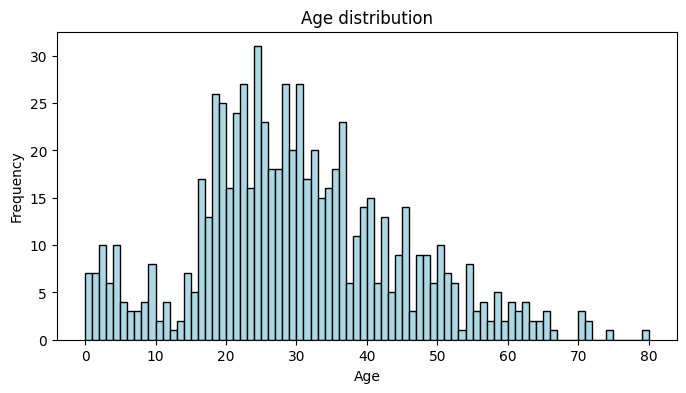

In [15]:
histogram(df, 'Age')

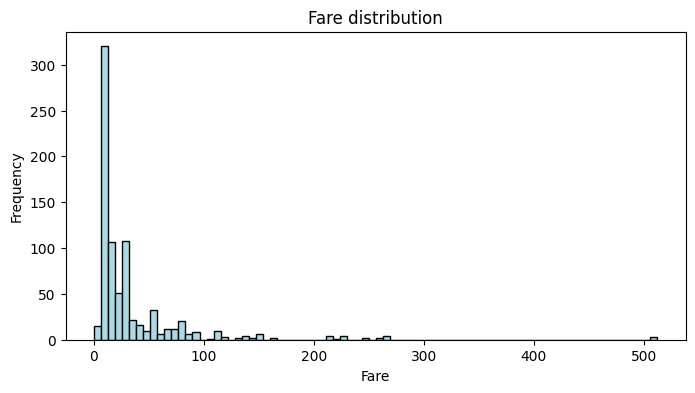

In [16]:
histogram(df, 'Fare')

Uzupełniam braki danych w kolumnach 'Age' i 'Fare' zgodnie rozkładu istniejących danych

In [17]:
def get_column_distribution(df, column):
  return df[column].value_counts(normalize = True)

In [18]:
def missing_vals_imputation(df, col):
  df_dist = get_column_distribution(df, col)

  df_values = df_dist.index
  df_probs = df_dist.values

  missing_df_col_values = df[col].isna()
  df.loc[missing_df_col_values, col] = np.random.choice(df_values, size = missing_df_col_values.sum(), p= df_probs)

  return df[col].isna().sum()

In [19]:
missing_vals_imputation(df, 'Age')

np.int64(0)

In [20]:
df.Age = df.Age.astype('int')
df.Age.dtype

dtype('int64')

In [21]:
missing_vals_imputation(df, 'Fare')

np.int64(0)

In [22]:
df.describe(include = 'object')

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


In [23]:
df['Ticket'].duplicated().sum()

np.int64(210)

210 osób posiadało współne bilety. Osoby z pierwszej i drugiej klasy z tym samym numerem biletu były zakwaterowane obok siebie. Osoby z trzeciej klasy były rozdzielane niezależnie od numeru biletu.

In [24]:
df['Cabin'].str[0].unique()

array([nan, 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T'], dtype=object)

In [25]:
df['Deck'] = df['Cabin'].str[0]
df = df.drop(columns = ['Cabin'])

Zmienna 'Deck' (pokład) redukuje wymiarowość oraz ułatwia uzupełnianie brakujących wartości ze względu na ogólność.

Uzupełniam pokłady zgodnie z numerem biletu dla osób z pierwszej i drugiej klasy.

In [26]:
df['Ticket'] = df['Ticket'].str.strip()

In [27]:
is_ticket_duplicated = df.Ticket.duplicated()
ticket_duplicates = df.loc[is_ticket_duplicated, 'Ticket'].unique()

In [28]:
same_ticket = df[(df['Ticket'].isin(ticket_duplicates)) & ((df['Pclass'] == 1) | (df['Pclass'] == 2))]
same_ticket

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Deck
PassengerId,,,,,,,,,,,
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,S,C
10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14,1,0,237736,30.0708,C,NaN
21,0,2,"Fynney, Mr. Joseph J",male,35,0,0,239865,26.0000,S,NaN
28,0,1,"Fortune, Mr. Charles Alexander",male,19,3,2,19950,263.0000,S,C
32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,21,1,0,PC 17569,146.5208,C,B
...,...,...,...,...,...,...,...,...,...,...,...
857,1,1,"Wick, Mrs. George Dennick (Mary Hitchcock)",female,45,1,1,36928,164.8667,S,NaN
872,1,1,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",female,47,1,1,11751,52.5542,S,D
875,1,2,"Abelson, Mrs. Samuel (Hannah Wizosky)",female,28,1,0,P/PP 3381,24.0000,C,NaN


In [29]:
def get_cabins(df, ticket_duplicates):

  for t in ticket_duplicates:
    for k in df.Deck.dropna().unique():
      if ((df['Ticket'] == t) & (df['Deck'] == k)).any():
        df.loc[(df['Ticket'] == t) & (df['Deck'].isna()), 'Deck'] = k
  return df

In [30]:
print(f'Braki danych przed funkcją: {same_ticket['Deck'].isna().sum()}')

Braki danych przed funkcją:88


In [31]:
same_ticket = get_cabins(same_ticket, ticket_duplicates)

In [32]:
print(f'Braki danych teraz: {same_ticket['Deck'].isna().sum()}')

Braki danych teraz: 78


In [33]:
df.loc[(df['Ticket'].isin(ticket_duplicates)) & ((df['Pclass'] == 1) | (df['Pclass'] == 2)), 'Deck'] = same_ticket['Deck']

In [34]:
df.groupby('Pclass')['Deck'].value_counts()

Pclass  Deck
1       C       67
        B       48
        D       29
        E       25
        A       15
        T        1
2       F        8
        E        5
        D        4
3       F        5
        G        4
        E        3
Name: count, dtype: int64

Każda klasa była przypisana do określonych pokładów, dlatego uzupełnienie braków zgodnie z ogólnym rozkładem danych może zaburzyć wynik. Na przykład, przypisać osobę z klasy 3 do pokładu na którym są tylko osoby z klasy 1 lub 2.

In [35]:
first_class_df = df[df['Pclass'] == 1]
second_class_df = df[df['Pclass'] == 2]
third_class_df = df[df['Pclass'] == 3]

In [36]:
def missing_vals_imputation(df, col):
  df_dist = get_column_distribution(df, col)

  df_values = df_dist.index
  df_probs = df_dist.values

  missing_df_col_values = df[col].isna()
  df.loc[missing_df_col_values, col] = np.random.choice(df_values, size = missing_df_col_values.sum(), p= df_probs)

  return df[col].isna().sum()

In [37]:
print(missing_vals_imputation(first_class_df, 'Deck'))
print(missing_vals_imputation(second_class_df, 'Deck'))
print(missing_vals_imputation(third_class_df, 'Deck'))

0
0
0


In [38]:
df = pd.concat([first_class_df, second_class_df, third_class_df]).sort_index()

In [39]:
df['Deck'] = df['Deck'].astype(pd.CategoricalDtype(categories=['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T'], ordered=True))

In [40]:
get_column_distribution(df, 'Embarked')

,proportion
Embarked,
S,0.724409
C,0.188976
Q,0.086614


In [41]:
df.Embarked.isna().sum()

np.int64(2)

Tworzenie sztucznej kategorii dla dwóch braków się nie opłaca oraz kolumna posiada dominującą wartość S, dlatego optymalnym rozwiązaniem jest uzupełnienie tych braków najczęstszą wartością

In [42]:
df.Embarked = df.Embarked.fillna('S')

In [43]:
df.Embarked.isna().sum()

np.int64(0)

# Feature Engineering

Historycznie, osoby z różnych klas były rozmieszczane w określonych częściach statku. Klasa pierwsza zajmowała środek, klasa druga była przesunięta ku rufie, a osoby z klasy trzeciej były dzielone na samotnych mężczyzn na dziobie oraz rodziny i kobiety na rufie. Ze względu na ten podział można utworzyć nową cechę 'Section'.

In [81]:
pclass_3_male_alone = df[(df['Pclass'] == 3) & (df['Parch'] == 0) & (df['Sex'] == 'male')]
pclass_3_male_alone.head(2)


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Deck,Section,People_On_Ticket,Fare_per_person,Wealth_level
PassengerId,,,,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.25,S,F,bow,1,7.25,lower_class
5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.05,S,G,bow,1,8.05,lower_class


In [82]:
pclass_3_other = df[(df['Pclass'] == 3) & ~(df.index.isin(pclass_3_male_alone.index))]
pclass_3_other.head(2)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Deck,Section,People_On_Ticket,Fare_per_person,Wealth_level
PassengerId,,,,,,,,,,,,,,,
3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.925,S,F,stern,1,7.92500,lower_class
8,0,3,"Palsson, Master. Gosta Leonard",male,2,3,1,349909,21.075,S,E,stern,4,5.26875,lower_class


In [83]:
pclass_1 = df[(df['Pclass'] == 1)]
pclass_1.head(2)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Deck,Section,People_On_Ticket,Fare_per_person,Wealth_level
PassengerId,,,,,,,,,,,,,,,
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C,C,midship,1,71.2833,wealthy
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,S,C,midship,2,26.5500,middle_class


In [47]:
df['Section'] = np.nan

In [48]:
for i in df.index:
  if i in pclass_3_male_alone.index:
    df.loc[i, 'Section'] = 'bow'
  elif i in pclass_3_other.index:
    df.loc[i, 'Section'] = 'stern'
  elif i in pclass_1.index:
    df.loc[i, 'Section'] = 'midship'
  else:
    df.loc[i, 'Section'] = 'midship_aft'

/tmp/ipykernel_114857/1454048111.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'bow' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[i, 'Section'] = 'bow'


Ceny biletów w klasie pierwszej są mocno zróżnicowane, co świadczy o różnym poziomie zamożności osób. Minimalny koszt wejścia do klasy pierwszej wynosił 30 funtów, jednak w danych pojawiają się o wiele większe kwoty np. 200 funtów. Nowa cecha "Wealth_level" będzie wskazywać poziom zamożności wszystkich osób.

Również, kolumna 'Fare' oznacza łączną cenę za bilet dla grupy. Dlatego, aby poprawnie wskazać poziom zamożności osób, obliczam przy duplikatach cenę na osobę.

In [49]:
people_on_ticket = df[df['Ticket'].isin(ticket_duplicates)]['Ticket'].value_counts()

df['People_On_Ticket'] = df['Ticket'].map(people_on_ticket)
df['People_On_Ticket'] = df['People_On_Ticket'].fillna(1)

df['People_On_Ticket'] = df['People_On_Ticket'].astype('int')

df['People_On_Ticket'].value_counts()

,count
People_On_Ticket,
1,547
2,188
3,63
4,44
7,21
6,18
5,10


In [50]:
df['Fare_per_person'] = df['Fare'] / df['People_On_Ticket']

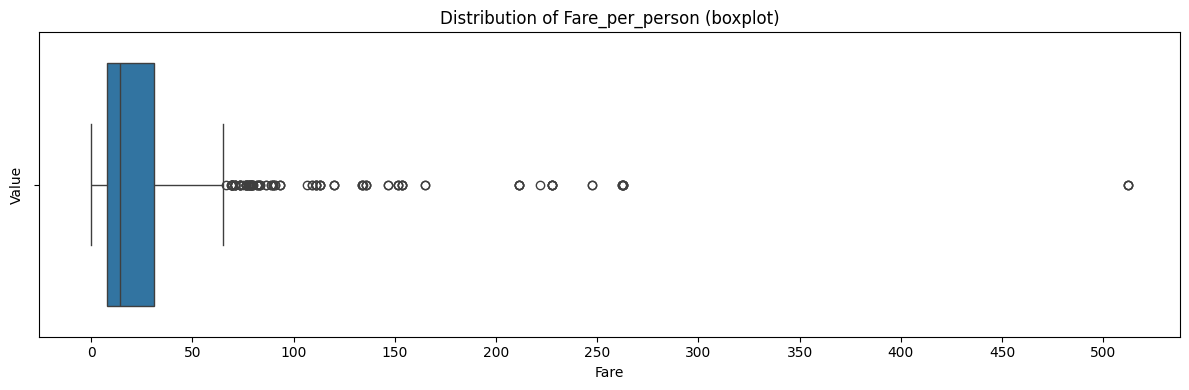

In [51]:
plt.figure(figsize=(12,4))
sns.boxplot(data = df, x = 'Fare')
plt.title(f"Distribution of Fare_per_person (boxplot)")
plt.ylabel("Value")
plt.xticks(np.arange(0, 550, step=50))
plt.tight_layout()
plt.show()

In [52]:
Q1 = df['Fare_per_person'].quantile(0.25)
Q3 = df['Fare_per_person'].quantile(0.75)
IQR = Q3-Q1
upper_bound = Q3 + (1.5 * IQR)
round(upper_bound, 2)

np.float64(53.36)

Większość osób bogatych 'upper_class' mieści się w przedziale od 30 do 53.23 funta. Powyżej są wartości odstające, przy czym są rozdzielone pustymi przedziałami w danych. Kwota 200 funtów znajduje się wewnątrz takiej luki, oraz po tej kwocie znajdują się najbardziej ekstremalne wartości. Dlatego 200 jest dobrą granicą między kategorią 'wealthy' (od 53.23 do 200) a 'elite'.

In [53]:
for i in df.index:
  if df.loc[i, 'Fare_per_person'] >= 200:
    df.loc[i, 'Wealth_level'] = 'elite'
  elif (df.loc[i, 'Fare_per_person'] >= 53.23) & (df.loc[i, 'Fare_per_person'] < 200):
    df.loc[i, 'Wealth_level'] = 'wealthy'
  elif (df.loc[i, 'Fare_per_person'] >= 30) & (df.loc[i, 'Fare_per_person'] < 53.23):
    df.loc[i, 'Wealth_level'] = 'upper_class'
  elif (df.loc[i, 'Fare_per_person'] >= 12) & (df.loc[i, 'Fare_per_person'] < 30):
    df.loc[i, 'Wealth_level'] = 'middle_class'
  else:
    df.loc[i, 'Wealth_level'] = 'lower_class'

In [54]:
df['Wealth_level'] = df['Wealth_level'].astype(pd.CategoricalDtype(categories=['lower_class', 'middle_class', 'upper_class', 'wealthy', 'elite'], ordered=True))

In [55]:
df.head(2)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Deck,Section,People_On_Ticket,Fare_per_person,Wealth_level
PassengerId,,,,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,S,F,bow,1,7.2500,lower_class
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C,C,midship,1,71.2833,wealthy


# Wizualizacja danych

In [56]:
numerical_cols = df.select_dtypes('number')

In [57]:
categorical_cols = df.select_dtypes(['object','category'])
categorical_cols = categorical_cols.drop(columns = ['Name', 'Ticket'])

In [58]:
def boxplots(df):

  fig, axis = plt.subplots(3, 3, figsize=(15, 10))
  axis = axis.flatten()

  for i, col in enumerate(df.columns):
    sns.boxplot(x=df[col], ax = axis[i], color='lightblue')
    axis[i].set_xlabel(col)

  plt.tight_layout()
  plt.show()

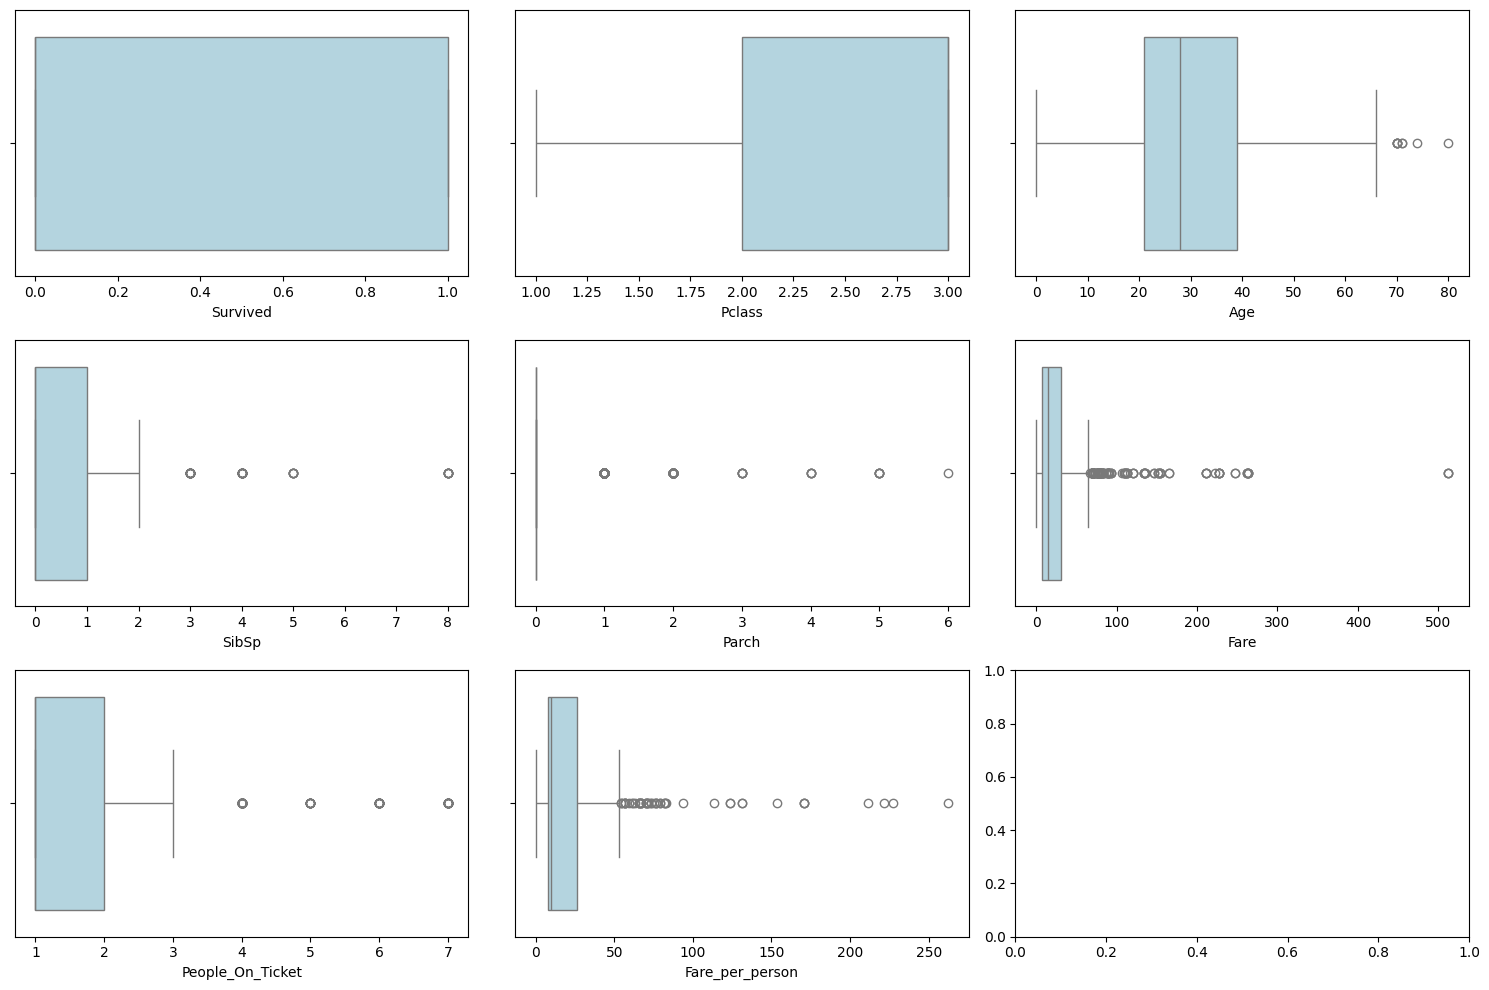

In [59]:
boxplots(numerical_cols)

Ważne jest pozostawienie informacji o cenach biletów, nawet tych odstających. Pozostałe zmienne również nie wymagają usuwania wartości odstających.

In [60]:
def barplots(df, y):
  fig, axis = plt.subplots((len(df.columns) + 1) // 2, 2, figsize=(10, 10))
  axis = axis.flatten()

  for i, col in enumerate(df.columns):
      sns.barplot(x=df[col], y=y, data=df, ax=axis[i], edgecolor='black', errorbar=None, color = 'lightblue')
      axis[i].set_title(f'Survival Rate by {col.capitalize()}')
      axis[i].set_xlabel(col.capitalize())
      axis[i].set_ylabel('Survival Rate')

  plt.tight_layout()
  plt.show()

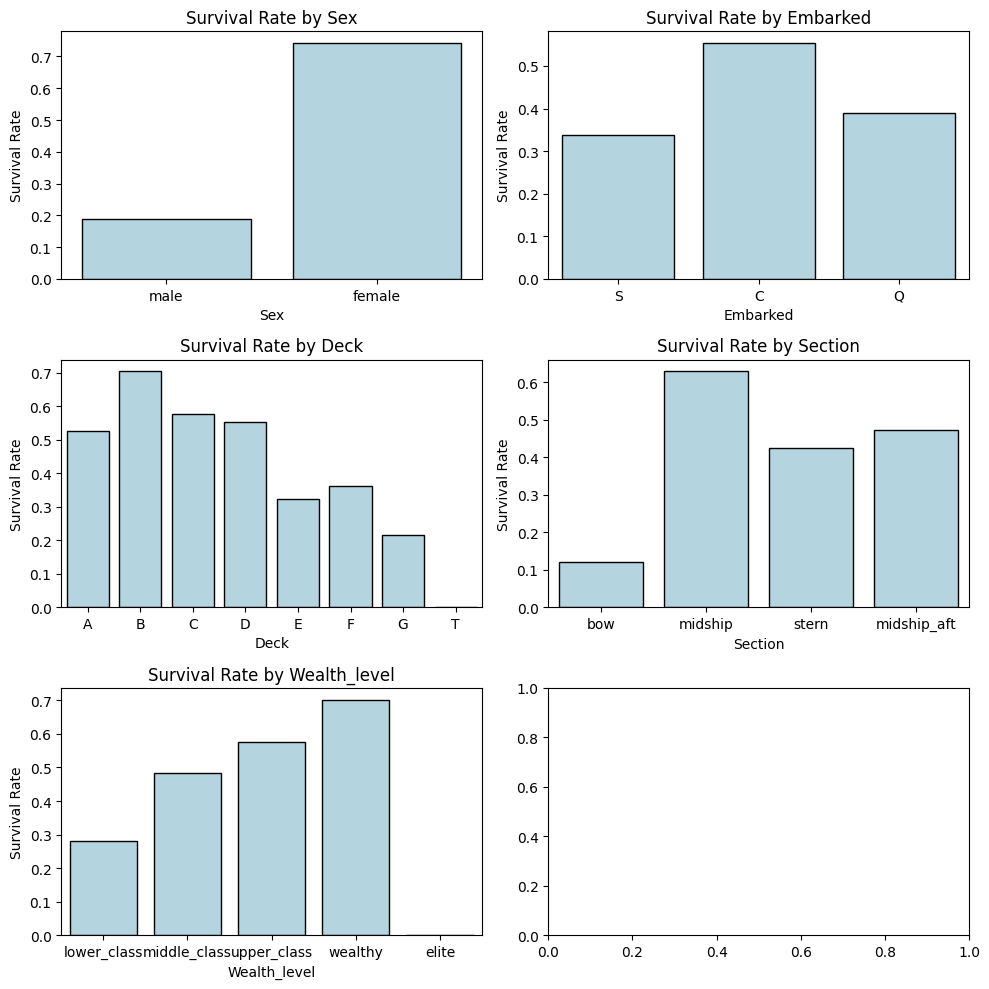

In [61]:
barplots(categorical_cols, df['Survived'])

Dzięki wykresom widać, że większe szanse na przeżycie miały kobiety, osoby zamożne, osoby ulokowane na wyższych pokładach i w środkowej części statku.

Najmniejsze szanse mieli mężczyźni, osoby uboższe oraz osoby ulokowane na dolnych pokładach i na dziobie statku.

In [62]:
numerical_cols['Age'] = pd.cut(numerical_cols['Age'], bins=4, labels=['0-20', '20-40', '40-60', '60-80'])

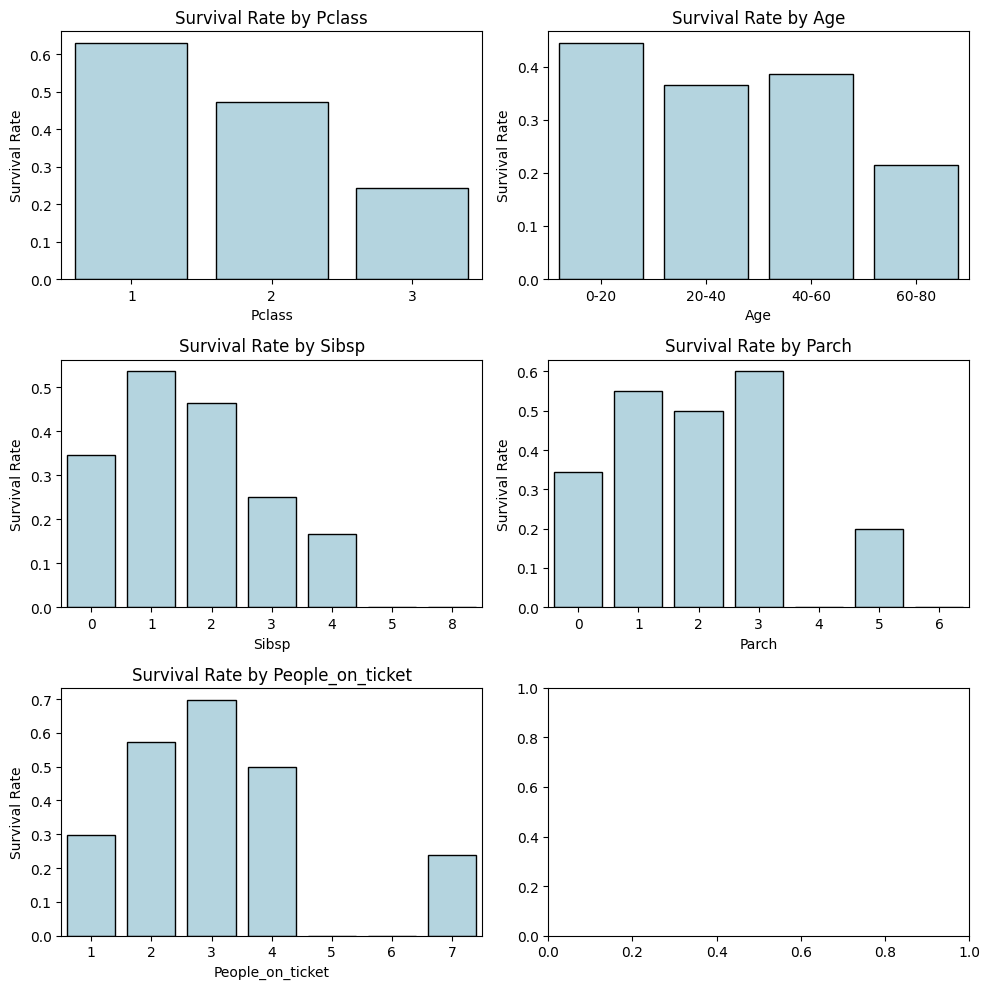

In [63]:
barplots(numerical_cols.drop(columns = ['Survived','Fare', 'Fare_per_person']), df['Survived'])

Najmniejsze szanse na przeżycie miały osoby należące do trzeciej klasy, osoby w wieku od 60 do 80 lat, członkowie dużych rodzin, osoby samotne

# Kodowanie kolumn

In [64]:
X = df.copy()

In [65]:
X = X.drop(columns = ['Survived', 'Name', 'Ticket', 'Fare'])

In [66]:
y = df['Survived']

In [67]:
X.head(5)

,Pclass,Sex,Age,SibSp,Parch,Embarked,Deck,Section,People_On_Ticket,Fare_per_person,Wealth_level
PassengerId,,,,,,,,,,,
1,3,male,22,1,0,S,F,bow,1,7.2500,lower_class
2,1,female,38,1,0,C,C,midship,1,71.2833,wealthy
3,3,female,26,0,0,S,F,stern,1,7.9250,lower_class
4,1,female,35,1,0,S,C,midship,2,26.5500,middle_class
5,3,male,35,0,0,S,G,bow,1,8.0500,lower_class


One_hot_encoding dla zmiennych nominalnych:

In [68]:
def one_hot_encoding(df, col):
  one_hot_encoded = pd.get_dummies(data = df, prefix = col, columns = [col], dtype = np.int32)
  return one_hot_encoded


In [69]:
X = one_hot_encoding(X, 'Sex')
X = one_hot_encoding(X, 'Section')
X = one_hot_encoding(X, 'Embarked')

Ordinal encoding dla zmiennych porządkowych:

In [70]:
mapping = {
    'elite': 1,
    'wealthy': 2,
    'upper_class': 3,
    'middle_class': 4,
    'lower_class': 5,
}

X['Wealth_level'] = X['Wealth_level'].map(mapping)

In [71]:
labels_mapping = {
    k: i for i, k in enumerate(sorted(X['Deck'].unique()))
}

X['Deck'] = X.Deck.map(labels_mapping)

In [72]:
X.loc[X['Deck'] == 7, 'Deck'] = 0

Pokład numer 7 (po kodowaniu) to jest kabina 'T', która znajdowała się na samej górze

In [73]:
X.head(5)

,Pclass,Age,SibSp,Parch,Deck,People_On_Ticket,Fare_per_person,Wealth_level,Sex_female,Sex_male,Section_bow,Section_midship,Section_midship_aft,Section_stern,Embarked_C,Embarked_Q,Embarked_S
PassengerId,,,,,,,,,,,,,,,,,
1,3,22,1,0,5,1,7.2500,5,0,1,1,0,0,0,0,0,1
2,1,38,1,0,2,1,71.2833,2,1,0,0,1,0,0,1,0,0
3,3,26,0,0,5,1,7.9250,5,1,0,0,0,0,1,0,0,1
4,1,35,1,0,2,2,26.5500,4,1,0,0,1,0,0,0,0,1
5,3,35,0,0,6,1,8.0500,5,0,1,1,0,0,0,0,0,1


# Zmiana zakresu wartości

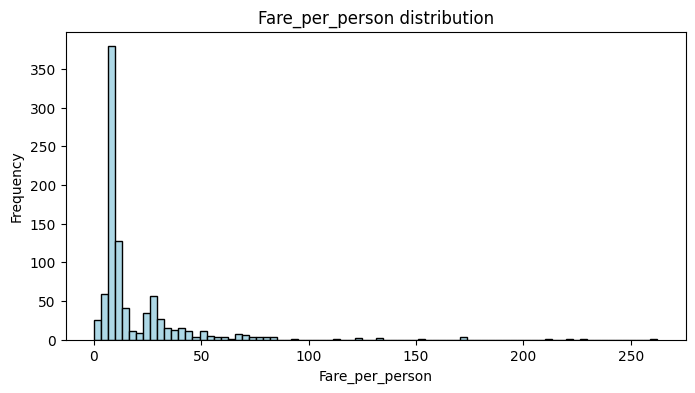

In [74]:
histogram(df, 'Fare_per_person')

Ze względu na to, że rozkład cen biletów ma wartości w zakresie od 0 do nieskończoności oraz jest prawoskośny, aby zmienić zakres wartości zmiennej stosuje się logarytmowanie

In [75]:
def logarytm(df, col):
  df[f'{col}_log'] = np.log1p(df[col])
  df = df.drop(columns = [col])
  return df

In [76]:
X = logarytm(X, 'Fare_per_person')

Kolumna 'Age' wymaga zmiany zakresu zmiennej ze względu na dużą różnice w skali w porównaniu do innych zmiennych

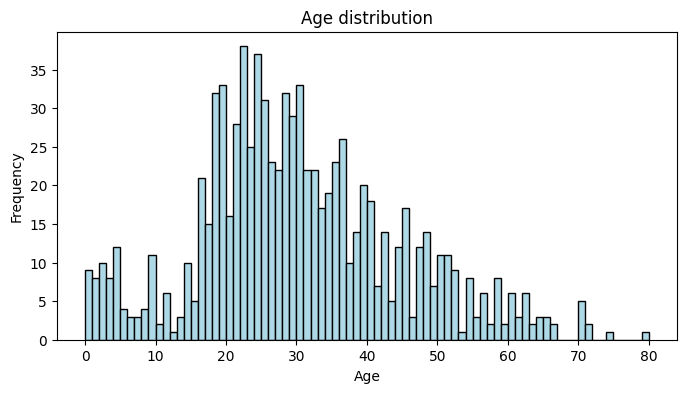

In [77]:
histogram(X, 'Age')

Rozkład prawoskośny, dlatego stosuję normalizację min-max a nie standaryzację

In [78]:
X['Age_normalized'] = (X['Age'] - X['Age'].min()) / (X['Age'].max() - X['Age'].min())

In [79]:
X = X.drop(columns = ['Age'])

# Wynik:

In [80]:
X.head()

,Pclass,SibSp,Parch,Deck,People_On_Ticket,Wealth_level,Sex_female,Sex_male,Section_bow,Section_midship,Section_midship_aft,Section_stern,Embarked_C,Embarked_Q,Embarked_S,Fare_per_person_log,Age_normalized
PassengerId,,,,,,,,,,,,,,,,,
1,3,1,0,5,1,5,0,1,1,0,0,0,0,0,1,2.110213,0.2750
2,1,1,0,2,1,2,1,0,0,1,0,0,1,0,0,4.280593,0.4750
3,3,0,0,5,1,5,1,0,0,0,0,1,0,0,1,2.188856,0.3250
4,1,1,0,2,2,4,1,0,0,1,0,0,0,0,1,3.316003,0.4375
5,3,0,0,6,1,5,0,1,1,0,0,0,0,0,1,2.202765,0.4375
